### Python Prescriptive Analytics - 2026-03-01 - Trejor6927

#### Summary Statistics

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


#### Feature Importance

,Feature,Importance
1,Social support,0.433915
2,Healthy life expectancy,0.225538
0,GDP per capita,0.212159
3,Freedom to make life choices,0.068114
5,Perceptions of corruption,0.032633
4,Generosity,0.027641


#### HDI Before and After Intervention

,Country or region,Score,Predicted HDI after intervention
78,Turkey,5.373,5.99850
79,Malaysia,5.339,5.40876
80,Belarus,5.323,6.11382
81,Greece,5.287,5.28268
82,Mongolia,5.285,5.78438
...,...,...,...
151,Rwanda,3.334,3.80575
152,Tanzania,3.231,3.80266
153,Afghanistan,3.203,4.05923
154,Central African Republic,3.083,3.74613


C:\Users\Student\AppData\Local\Temp\ipykernel_8884\1152342709.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


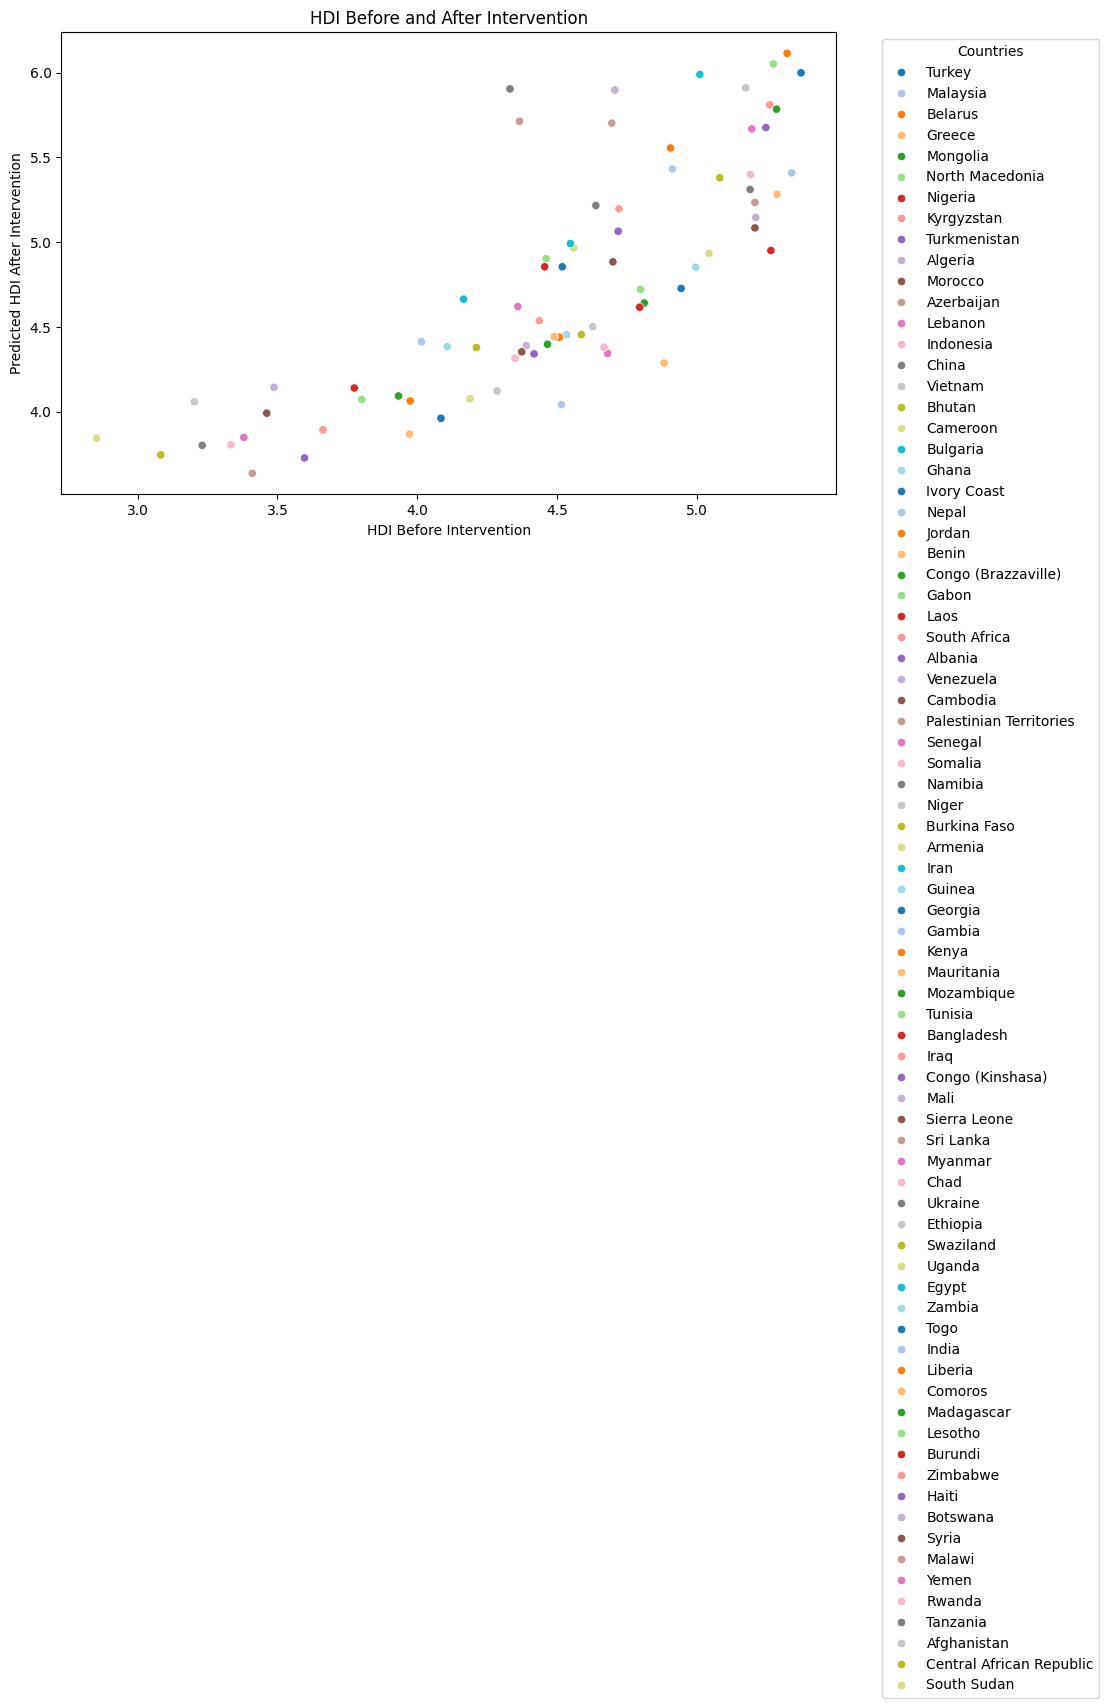

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from datetime import datetime
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "C:/Files/Excel/55project/2019_Happiness_Index_v4(2).xlsx"
happiness_df = pd.read_excel(file_path)

# Display header
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Trejor6927"
display(Markdown(f"### Python Prescriptive Analytics - {todays_date} - {student_id}"))

# Summary statistics
display(Markdown("#### Summary Statistics"))
display(happiness_df.describe())

# Features for analysis
features = ["GDP per capita", "Social support", "Healthy life expectancy", "Freedom to make life choices", "Generosity", "Perceptions of corruption"]

# Convert to numeric and coerce errors
for col in features + ["Score"]:
    happiness_df[col] = pd.to_numeric(happiness_df[col], errors="coerce")

# Drop rows with missing values in features or score
happiness_df = happiness_df.dropna(subset=features + ["Score"])

# Subset countries with HDI values less than the median (i.e., Score)
median_hdi = happiness_df['Score'].median()
low_hdi_countries = happiness_df[happiness_df['Score'] < median_hdi]

# Fit a RandomForestRegressor model for feature importance
X = happiness_df[features]
y = happiness_df["Score"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Calculate feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display feature importance
display(Markdown("#### Feature Importance"))
display(feature_importances)

# Simulate interventions on 'Healthy life expectancy' and 'Freedom to make life choices'
low_hdi_countries["Healthy life expectancy (new)"] = low_hdi_countries["Healthy life expectancy"] * 1.05  # Increase by 5%
low_hdi_countries["Freedom to make life choices (new)"] = low_hdi_countries["Freedom to make life choices"] + 1.5  # Increase by 1.5

# Rename the columns to match the original feature names used during model training
low_hdi_countries["Healthy life expectancy"] = low_hdi_countries["Healthy life expectancy (new)"]
low_hdi_countries["Freedom to make life choices"] = low_hdi_countries["Freedom to make life choices (new)"]

# Drop the new intervention columns, as they are no longer needed
low_hdi_countries = low_hdi_countries.drop(columns=["Healthy life expectancy (new)", "Freedom to make life choices (new)"])

# Predict HDI after intervention using the original features
X_new = low_hdi_countries[["GDP per capita", "Social support", "Healthy life expectancy", "Freedom to make life choices", "Generosity", "Perceptions of corruption"]]
low_hdi_countries["Predicted HDI after intervention"] = model.predict(X_new)

# Display the results of the intervention
display(Markdown("#### HDI Before and After Intervention"))
display(low_hdi_countries[["Country or region", "Score", "Predicted HDI after intervention"]])

# Plot the HDI before and after intervention
plt.figure(figsize=(10, 6))
sns.scatterplot(x=low_hdi_countries["Score"], y=low_hdi_countries["Predicted HDI after intervention"], hue=low_hdi_countries["Country or region"], palette="tab20")
plt.title("HDI Before and After Intervention")
plt.xlabel("HDI Before Intervention")
plt.ylabel("Predicted HDI After Intervention")
plt.legend(title="Countries", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()